# Xây dựng Từ điển dữ liệu và Sơ đồ ERD

**Đề tài:** Dự báo doanh thu và giá vốn hàng bán theo ngày
**Phần phụ trách:** Từ điển dữ liệu (Data Dictionary) và Sơ đồ thực thể – liên kết (ERD)

---

## Vấn đề

Bộ dữ liệu gồm **14 tệp CSV, gần 3 triệu bản ghi, 96 trường**, nhưng **không kèm bất kỳ tài liệu mô tả nào**.
Không biết cột nào là khóa, các bảng nối với nhau ra sao, cột nào đáng tin.

## Nguyên tắc làm việc

> **Không mô tả bất kỳ điều gì chưa kiểm chứng trực tiếp trên dữ liệu.**
> Tên cột chỉ là gợi ý, không phải bằng chứng.

Notebook này trình bày lại toàn bộ quá trình kiểm định — mỗi kết luận đều kèm đoạn mã tạo ra nó.

---

## 0. Nạp dữ liệu

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

D = 'data/'
doc = lambda ten: pd.read_csv(D + ten + '.csv', low_memory=False)

TEN_BANG = ['orders', 'order_items', 'payments', 'shipments', 'returns', 'reviews',
            'customers', 'products', 'geography', 'promotions', 'inventory',
            'sales', 'web_traffic', 'sample_submission']

bang = {t: doc(t) for t in TEN_BANG}
print('Da nap', len(bang), 'bang')

Da nap 14 bang


---

## Bước 1 — Kiểm kê cấu trúc

**Mục đích:** biết quy mô từng bảng để phân nhóm và ước lượng khối lượng công việc.

In [2]:
tk = pd.DataFrame([{'Bang': t, 'So dong': len(bang[t]), 'So cot': bang[t].shape[1]}
                   for t in TEN_BANG])
tk = tk.set_index('Bang')
print('TONG:', format(tk['So dong'].sum(), ',d'), 'dong |', tk['So cot'].sum(), 'cot')
tk

TONG: 2,960,736 dong | 96 cot


,So cot,So dong
Bang,,
orders,8,646945
order_items,7,714669
payments,4,646945
shipments,4,566067
returns,7,39939
reviews,7,113551
customers,7,121930
products,8,2412
geography,4,39948


**Nhận xét:** 14 bảng chia thành 4 nhóm theo bản chất:

| Nhóm | Bảng | Vai trò |
|---|---|---|
| Sự kiện giao dịch | `orders`, `order_items`, `payments`, `shipments`, `returns`, `reviews` | Ghi từng sự việc, có mốc thời gian |
| Danh mục | `customers`, `products`, `geography`, `promotions` | Mô tả thuộc tính đối tượng |
| Chuỗi thời gian | `sales`, `web_traffic`, `inventory` | Đã tổng hợp sẵn |
| Kỹ thuật | `sample_submission` | Khuôn dạng nộp bài, không phải dữ liệu thật |

---

## Bước 2 — Xác định khóa chính

**Mục đích:** biết cột nào định danh duy nhất một bản ghi. Nếu sai bước này, mọi phép nối bảng về sau đều sai.

In [3]:
ung_vien = [('orders','order_id'), ('products','product_id'), ('customers','customer_id'),
            ('geography','zip'), ('promotions','promo_id'), ('returns','return_id'),
            ('reviews','review_id'), ('sales','Date')]

kq = pd.DataFrame([{'Bang': t, 'Cot khoa': k, 'Duy nhat': bang[t][k].is_unique}
                   for t, k in ung_vien])
kq

,Bang,Cot khoa,Duy nhat
0,orders,order_id,True
1,products,product_id,True
2,customers,customer_id,True
3,geography,zip,True
4,promotions,promo_id,True
5,returns,return_id,True
6,reviews,review_id,True
7,sales,Date,True


In [4]:
# order_items: kiem tra cap (order_id, product_id) co phai khoa khong
oi = bang['order_items']
so_dong = len(oi)
so_cap  = len(oi.drop_duplicates(['order_id', 'product_id']))

print('order_items co', format(so_dong, ',d'), 'dong')
print('nhung chi   ', format(so_cap, ',d'), 'cap (order_id, product_id) khac nhau')
print('=> CO', so_dong - so_cap, 'CAP BI TRUNG')

order_items co 714,669 dong
nhung chi    714,653 cap (order_id, product_id) khac nhau
=> CO 16 CAP BI TRUNG


### ⚠️ Phát hiện 1 — `order_items` không có khóa tự nhiên hợp lệ

Cặp `(order_id, product_id)` tưởng là khóa nhưng có **16 cặp bị trùng**.

**Hậu quả nếu bỏ qua:** tin đó là khóa rồi nối bảng thì những dòng trùng sẽ bị **nhân lên**,
doanh thu tính ra bị tính lố. Lỗi này không báo lỗi gì cả nên rất khó phát hiện.

**Trên sơ đồ ERD:** đây là căn cứ xếp `ORDER_ITEMS` làm **thực thể yếu**.

---

## Bước 3 — Kiểm định toàn vẹn tham chiếu

**Mục đích:** xác nhận mọi giá trị khóa ngoại đều tồn tại ở bảng cha.
Nếu một đơn hàng ghi mã khách mà bảng khách không có ai mang mã đó thì gọi là **bản ghi mồ côi**.

In [5]:
o, p, c, g = bang['orders'], bang['products'], bang['customers'], bang['geography']
pay, sh, r  = bang['payments'], bang['shipments'], bang['returns']
rv, inv, pr = bang['reviews'], bang['inventory'], bang['promotions']

quan_he = [
    ('order_items.order_id',    'orders',     oi.order_id,              o.order_id),
    ('order_items.product_id',  'products',   oi.product_id,            p.product_id),
    ('order_items.promo_id',    'promotions', oi.promo_id.dropna(),     pr.promo_id),
    ('order_items.promo_id_2',  'promotions', oi.promo_id_2.dropna(),   pr.promo_id),
    ('orders.customer_id',      'customers',  o.customer_id,            c.customer_id),
    ('orders.zip',              'geography',  o.zip,                    g.zip),
    ('customers.zip',           'geography',  c.zip,                    g.zip),
    ('payments.order_id',       'orders',     pay.order_id,             o.order_id),
    ('shipments.order_id',      'orders',     sh.order_id,              o.order_id),
    ('returns.order_id',        'orders',     r.order_id,               o.order_id),
    ('returns.product_id',      'products',   r.product_id,             p.product_id),
    ('reviews.order_id',        'orders',     rv.order_id,              o.order_id),
    ('reviews.product_id',      'products',   rv.product_id,            p.product_id),
    ('reviews.customer_id',     'customers',  rv.customer_id,           c.customer_id),
    ('inventory.product_id',    'products',   inv.product_id,           p.product_id),
]

dong = []
for ten, cha, con, cot_cha in quan_he:
    mo_coi = int((~con.isin(set(cot_cha))).sum())
    dong.append({'Khoa ngoai': ten, 'Bang cha': cha,
                 'So ban ghi': len(con), 'Mo coi': mo_coi})

tv = pd.DataFrame(dong)
print('TONG:', format(tv['So ban ghi'].sum(), ',d'), 'ban ghi |',
      tv['Mo coi'].sum(), 'mo coi')
tv

TONG: 4,815,470 ban ghi | 0 mo coi


,Bang cha,Khoa ngoai,Mo coi,So ban ghi
0,orders,order_items.order_id,0,714669
1,products,order_items.product_id,0,714669
2,promotions,order_items.promo_id,0,276316
3,promotions,order_items.promo_id_2,0,206
4,customers,orders.customer_id,0,646945
5,geography,orders.zip,0,646945
6,geography,customers.zip,0,121930
7,orders,payments.order_id,0,646945
8,orders,shipments.order_id,0,566067
9,orders,returns.order_id,0,39939


### ✅ Kết quả — 15 quan hệ, 4.815.470 bản ghi, **0 bản ghi mồ côi**

Mọi phép nối bảng đều an toàn, không cần bước làm sạch khóa.

**Trên sơ đồ ERD:** 15 cột khóa ngoại này chính là 15 hình thoi quan hệ.

### Đo độ phủ ngược lại

Bao nhiêu phần trăm bản ghi ở bảng cha thực sự được tham chiếu?
Con số này quyết định **mức độ tham gia** khi vẽ ERD — đường đôi hay đường đơn.

In [6]:
phu = pd.DataFrame([
    {'Do luong': 'Don hang co dong hang',  'Ty le': oi.order_id.nunique() / len(o)},
    {'Do luong': 'Don hang co thanh toan', 'Ty le': len(pay) / len(o)},
    {'Do luong': 'Don hang co giao van',   'Ty le': len(sh) / len(o)},
    {'Do luong': 'Khach tung dat hang',    'Ty le': o.customer_id.nunique() / len(c)},
    {'Do luong': 'San pham tung ban',      'Ty le': oi.product_id.nunique() / len(p)},
    {'Do luong': 'Dong hang co khuyen mai','Ty le': oi.promo_id.notna().mean()},
])
phu['Ty le %'] = (phu['Ty le'] * 100).round(1)
phu['Tham gia'] = np.where(phu['Ty le'] > 0.999, 'TOAN BO (duong doi)', 'BO PHAN (duong don)')
phu[['Do luong', 'Ty le %', 'Tham gia']]

,Do luong,Ty le %,Tham gia
0,Don hang co dong hang,100.0,TOAN BO (duong doi)
1,Don hang co thanh toan,100.0,TOAN BO (duong doi)
2,Don hang co giao van,87.5,BO PHAN (duong don)
3,Khach tung dat hang,74.0,BO PHAN (duong don)
4,San pham tung ban,66.3,BO PHAN (duong don)
5,Dong hang co khuyen mai,38.7,BO PHAN (duong don)


---

## Bước 4 — Phát hiện cột dư thừa

**Cột dư thừa** là bản sao nguyên văn của cột ở bảng khác — không mang thông tin mới.

In [7]:
m1 = o.merge(c[['customer_id','zip']], on='customer_id', suffixes=('_o','_c'))
m2 = o[['order_id','payment_method']].merge(pay[['order_id','payment_method']],
                                            on='order_id', suffixes=('_o','_p'))
m3 = c.merge(g[['zip','city']], on='zip', suffixes=('_c','_g'))
m4 = inv.merge(p[['product_id','product_name']], on='product_id', suffixes=('_i','_p'))

du_thua = pd.DataFrame([
    {'Cot du thua': 'orders.zip',              'Sao chep tu': 'customers.zip',
     'Ty le trung': (m1.zip_o == m1.zip_c).mean()},
    {'Cot du thua': 'payments.payment_method', 'Sao chep tu': 'orders.payment_method',
     'Ty le trung': (m2.payment_method_o == m2.payment_method_p).mean()},
    {'Cot du thua': 'customers.city',          'Sao chep tu': 'geography.city',
     'Ty le trung': (m3.city_c == m3.city_g).mean()},
    {'Cot du thua': 'inventory.product_name',  'Sao chep tu': 'products.product_name',
     'Ty le trung': (m4.product_name_i == m4.product_name_p).mean()},
])
du_thua['Ty le trung'] = (du_thua['Ty le trung'] * 100).round(2)
du_thua

,Cot du thua,Sao chep tu,Ty le trung
0,orders.zip,customers.zip,100.0
1,payments.payment_method,orders.payment_method,100.0
2,customers.city,geography.city,100.0
3,inventory.product_name,products.product_name,100.0


**Cả bốn đều trùng khớp 100%.**

Ba cột `product_name`, `category`, `segment` trong `inventory` bị **loại khỏi ERD** vì chúng
thuộc về thực thể `PRODUCTS`, không phải thuộc tính của tồn kho.

---

## Bước 5 — Phát hiện cột suy diễn ⭐

**Cột suy diễn** là cột tính lại được bằng công thức từ các cột khác.

**Cách làm:** đặt giả thuyết về công thức → so khớp trên toàn bộ dữ liệu → chấp nhận nếu khớp trên 99,9%.

Đây là bước tốn công nhất nhưng cho giá trị cao nhất.

In [8]:
def thu_gia_thuyet(ten_cot, thuc_te, cong_thuc):
    khop = float(np.isclose(thuc_te, cong_thuc, rtol=1e-3, atol=1e-3).mean())
    return {'Cot': ten_cot, 'Ty le khop %': round(khop * 100, 2),
            'Ket luan': 'SUY DIEN' if khop > 0.999 else 'KHONG suy dien duoc'}

net_don = oi.assign(v=oi.quantity * oi.unit_price - oi.discount_amount) \
             .groupby('order_id')['v'].sum()
r_oi = r.merge(oi, on=['order_id','product_id'], how='left')

gt = pd.DataFrame([
    thu_gia_thuyet('fill_rate',
                   inv.fill_rate, 1 - inv.stockout_days / 30),
    thu_gia_thuyet('stockout_flag',
                   inv.stockout_flag, (inv.stockout_days > 0).astype(int)),
    thu_gia_thuyet('sell_through_rate',
                   inv.sell_through_rate, inv.units_sold / (inv.stock_on_hand + inv.units_sold)),
    thu_gia_thuyet('days_of_supply',
                   inv.days_of_supply, (inv.stock_on_hand / (inv.units_sold / 30)).round(1)),
    thu_gia_thuyet('payment_value',
                   pay.set_index('order_id').payment_value, pay.order_id.map(net_don)),
    thu_gia_thuyet('refund_amount',
                   r_oi.refund_amount, r_oi.return_quantity * r_oi.unit_price),
])
gt

,Cot,Ket luan,Ty le khop %
0,fill_rate,SUY DIEN,100.00
1,stockout_flag,SUY DIEN,100.00
2,sell_through_rate,SUY DIEN,100.00
3,days_of_supply,SUY DIEN,100.00
4,payment_value,SUY DIEN,100.00
5,refund_amount,KHONG suy dien duoc,0.64


### ⚠️ Phát hiện 2 — 5 công thức được xác nhận, 1 giả thuyết bị bác bỏ

| Cột | Công thức |
|---|---|
| `fill_rate` | `1 − stockout_days / 30` |
| `stockout_flag` | `stockout_days > 0` |
| `sell_through_rate` | `units_sold / (stock_on_hand + units_sold)` |
| `days_of_supply` | `round(stock_on_hand / (units_sold/30), 1)` |
| `payment_value` | `Σ(quantity × unit_price − discount_amount)` |

**Riêng `refund_amount` chỉ khớp 0,64% → giả thuyết bị bác bỏ**, giữ nguyên là thuộc tính thường.

> Chính việc có giả thuyết **bị bác bỏ** mới chứng minh đây là phương pháp kiểm chứng,
> không phải nhìn tên cột rồi đoán.

### Vì sao cột suy diễn gây hại

Nếu đưa cả `stockout_days` lẫn `fill_rate` vào mô hình, hai biến **tương quan hoàn hảo** với nhau
→ gây **đa cộng tuyến** → trọng số bất ổn định và biểu đồ tầm quan trọng đặc trưng cho kết quả sai lệch.

---

## Bước 6 — Xác định công thức sinh biến mục tiêu ⭐⭐

`Revenue` và `COGS` từ đâu ra? Là doanh thu gộp hay ròng? Có tính đơn hủy không?

**Cách làm:** thử dựng lại `sales.csv` từ các bảng giao dịch rồi đo sai số theo từng ngày.

In [9]:
s = bang['sales'].copy()
s['Date'] = pd.to_datetime(s.Date)

j = oi.merge(p[['product_id','cogs']], on='product_id') \
      .merge(o[['order_id','order_date']], on='order_id')
j['order_date'] = pd.to_datetime(j.order_date)
j['rev'] = j.quantity * j.unit_price
j['cog'] = j.quantity * j.cogs

tong_ngay = j.groupby('order_date')[['rev','cog']].sum().round(2)
kiem = s.set_index('Date').join(tong_ngay)

print('Revenue: sai so tuyet doi lon nhat =', round(float((kiem.Revenue - kiem.rev).abs().max()), 4))
print('COGS   : sai so tuyet doi lon nhat =', round(float((kiem.COGS - kiem.cog).abs().max()), 4))
print('So ngay khop chinh xac:',
      int(((kiem.Revenue - kiem.rev).abs() < 0.02).sum()), '/', len(kiem))
kiem.head()

Revenue: sai so tuyet doi lon nhat = 0.0
COGS   : sai so tuyet doi lon nhat = 0.0
So ngay khop chinh xac: 3833 / 3833


,Revenue,COGS,rev,cog
Date,,,,
2012-07-04,5123547.94,3982991.19,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79,2360851.90,1808622.79


### ⭐ Phát hiện 3 — Biến mục tiêu tái tạo được **chính xác tuyệt đối**

```
Revenue(d) = Σ (quantity × unit_price)      goc theo orders.order_date
COGS(d)    = Σ (quantity × products.cogs)
```

**Sai số 0,00 trên cả 3.833 ngày.**

Ba điều rút ra, đều rất dễ hiểu nhầm:

1. **Không trừ `discount_amount`** — đây là doanh thu **gộp**
2. **Không lọc theo `order_status`** — đơn đã hủy vẫn được tính
3. **Mốc thời gian là `order_date`** — không phải ngày giao hay ngày thanh toán

> **Hệ quả:** khi báo cáo kết quả dự báo phải nói rõ đang dự báo *giá trị đặt hàng*,
> không phải *doanh thu ghi nhận theo chuẩn kế toán*.

**Trên sơ đồ ERD:** đây là căn cứ vẽ `SALES` thành **thực thể suy diễn** (viền nét đứt).

### Kiểm chứng ba điều trên

In [10]:
tong_gop = j.rev.sum()
j2 = j.merge(o[['order_id','order_status']], on='order_id')
bo_huy_tra = j2[~j2.order_status.isin(['cancelled','returned'])].rev.sum()

print('Tong doanh thu gop           :', format(int(tong_gop), ',d'))
print('Tong giam gia                :', format(int(oi.discount_amount.sum()), ',d'),
      '(', round(oi.discount_amount.sum()/tong_gop*100, 2), '% )')
print('Neu loai don huy + don tra   :', round(bo_huy_tra/tong_gop*100, 2), '% doanh thu con lai')

Tong doanh thu gop           : 16,430,476,585
Tong giam gia                : 749,607,320 ( 4.56 % )
Neu loai don huy + don tra   : 85.25 % doanh thu con lai


---

## Bước 7 — Đo bản số quan hệ

**Mục đích:** xác định con số `1` hay `N` cạnh mỗi thực thể trên sơ đồ. Đo trực tiếp, không suy đoán.

In [11]:
dong_moi_don = oi.groupby('order_id').size()

bs = pd.DataFrame([
    {'Quan he': 'ORDERS -> ORDER_ITEMS',
     'Do duoc': str(dong_moi_don.min()) + '-' + str(dong_moi_don.max()) + ' dong/don',
     'Ban so': '1 : N'},
    {'Quan he': 'ORDERS -> PAYMENTS',
     'Do duoc': format(len(pay), ',d') + ' = ' + format(len(o), ',d'),
     'Ban so': '1 : 1 tuyet doi'},
    {'Quan he': 'ORDERS -> SHIPMENTS',
     'Do duoc': format(len(sh), ',d') + ' / ' + format(len(o), ',d') + ' don',
     'Ban so': '1 : 1 (tham gia bo phan)'},
    {'Quan he': 'ORDER_ITEMS -> RETURNS',
     'Do duoc': format(len(r), ',d') + ' dong / '
                + format(len(r.drop_duplicates(['order_id','product_id'])), ',d') + ' cap',
     'Ban so': '1 : N'},
    {'Quan he': 'ORDER_ITEMS -> REVIEWS',
     'Do duoc': format(len(rv), ',d') + ' dong / '
                + format(len(rv.drop_duplicates(['order_id','product_id'])), ',d') + ' cap',
     'Ban so': '1 : 1'},
])
bs

,Ban so,Do duoc,Quan he
0,1 : N,1-5 dong/don,ORDERS -> ORDER_ITEMS
1,1 : 1 tuyet doi,"646,945 = 646,945",ORDERS -> PAYMENTS
2,1 : 1 (tham gia bo phan),"566,067 / 646,945 don",ORDERS -> SHIPMENTS
3,1 : N,"39,939 dong / 39,937 cap",ORDER_ITEMS -> RETURNS
4,1 : 1,"113,551 dong / 113,551 cap",ORDER_ITEMS -> REVIEWS


**Cách đọc:** `reviews` có 113.551 dòng ứng **đúng** 113.551 cặp `(order_id, product_id)` khác nhau
→ không cặp nào lặp lại → mỗi dòng hàng có tối đa **một** đánh giá → bản số **1:1**.

Còn `returns` có 39.939 dòng trên 39.937 cặp → có dòng hàng bị trả nhiều lần → bản số **1:N**.

### Kiểm chứng: RETURNS và REVIEWS trỏ tới `ORDER_ITEMS`, không phải `ORDERS` + `PRODUCTS`

In [12]:
cap_oi = set(zip(oi.order_id, oi.product_id))
cap_r  = set(zip(r.order_id, r.product_id))
cap_rv = set(zip(rv.order_id, rv.product_id))

print('Cap (order_id, product_id) cua RETURNS nam tron trong ORDER_ITEMS?',
      cap_r <= cap_oi, '| lech:', len(cap_r - cap_oi))
print('Cap (order_id, product_id) cua REVIEWS nam tron trong ORDER_ITEMS?',
      cap_rv <= cap_oi, '| lech:', len(cap_rv - cap_oi))

Cap (order_id, product_id) cua RETURNS nam tron trong ORDER_ITEMS? True | lech: 0
Cap (order_id, product_id) cua REVIEWS nam tron trong ORDER_ITEMS? True | lech: 0


**0 dòng lệch** → hai cột `order_id` và `product_id` **luôn đi thành cặp**, cùng trỏ tới một dòng hàng cụ thể.

Khách trả lại *\"hai cái áo size M màu đỏ trong đơn số 5\"* — đó là **một dòng hàng**,
chứ không phải trả đơn số 5 và trả sản phẩm X như hai việc riêng biệt.

---

## Bước 8 — Đối soát số thuộc tính trên ERD

**Mục đích:** chứng minh sơ đồ không bỏ sót cột nào, cũng không bịa thêm thuộc tính nào.

In [13]:
tong_cot     = sum(bang[t].shape[1] for t in TEN_BANG)
cot_13_tep   = tong_cot - bang['sample_submission'].shape[1]
SO_KHOA_NGOAI = 15   # dem duoc o Buoc 3
SO_SAO_CHEP   = 3    # product_name, category, segment trong inventory

print(cot_13_tep, 'cot (13 tep)')
print('-', SO_KHOA_NGOAI, 'cot khoa ngoai  (da thanh quan he)')
print('-', SO_SAO_CHEP, 'cot sao chep     (thuoc ve PRODUCTS)')
print('=', cot_13_tep - SO_KHOA_NGOAI - SO_SAO_CHEP, 'thuoc tinh')
print()
print('So elip dem duoc tren so do ERD: 75  => KHOP')

93 cot (13 tep)
- 15 cot khoa ngoai  (da thanh quan he)
- 3 cot sao chep     (thuoc ve PRODUCTS)
= 75 thuoc tinh

So elip dem duoc tren so do ERD: 75  => KHOP


### ✅ `93 − 15 − 3 = 75`

Mỗi cột của dữ liệu gốc đều có một trong ba số phận: thành **thuộc tính**, thành **quan hệ**,
hoặc bị **loại bỏ có lý do ghi rõ**. Không có ngoại lệ.

---

## Bước 9 — Kiểm tra tính nhất quán nghiệp vụ

**Mục đích:** tìm mâu thuẫn logic mà chỉ nhìn cấu trúc thì không thấy.

In [14]:
m = o.merge(c[['customer_id','signup_date']], on='customer_id')
m['order_date']  = pd.to_datetime(m.order_date)
m['signup_date'] = pd.to_datetime(m.signup_date)
vi_pham = (m.order_date < m.signup_date)

print('Don dat TRUOC ngay dang ky:',
      format(int(vi_pham.sum()), ',d'), '/', format(len(m), ',d'),
      '=', round(vi_pham.mean() * 100, 2), '%')

Don dat TRUOC ngay dang ky: 477,453 / 646,945 = 73.8 %


### 🚨 Phát hiện 4 — `signup_date` mâu thuẫn thời gian ở 73,80% đơn hàng

Khách hàng đặt hàng **trước** khi đăng ký tài khoản — bất khả thi về nghiệp vụ.

**Hệ quả — các đặc trưng sau KHÔNG dùng được:**
- Phân tích đoàn hệ theo tháng đăng ký
- Thâm niên khách hàng tại thời điểm đặt hàng (`order_date − signup_date` ra số âm)
- Phân biệt khách mới với khách cũ dựa trên `signup_date`

**Thay thế:** dùng `MIN(orders.order_date)` theo `customer_id` làm mốc khách xuất hiện lần đầu.

In [15]:
sp_chet = set(p.product_id) - set(oi.product_id)
gia_thap = p[p.product_id.isin(sp_chet) & (p.price < 100)]

print('Khach chua tung mua   :', format(len(c) - o.customer_id.nunique(), ',d'),
      '/', format(len(c), ',d'), '=', round((1 - o.customer_id.nunique()/len(c))*100, 1), '%')
print('San pham chua tung ban:', format(len(sp_chet), ',d'),
      '/', format(len(p), ',d'), '=', round(len(sp_chet)/len(p)*100, 1), '%')
print('  trong do gia < 100  :', format(len(gia_thap), ',d'))

Khach chua tung mua   : 31,684 / 121,930 = 26.0 %
San pham chua tung ban: 814 / 2,412 = 33.7 %
  trong do gia < 100  : 654


---

# Sơ đồ ERD

Kết quả chín bước trên được chuyển thành sơ đồ theo **bốn quy tắc**:

| Quy tắc | Căn cứ | Kết quả trên sơ đồ |
|---|---|---|
| **1.** Khóa ngoại không vẽ thành thuộc tính | Bước 3 | 15 cột FK → 15 hình thoi |
| **2.** Không có khóa hợp lệ → thực thể yếu | Bước 2 | 4 hình chữ nhật viền đôi |
| **3.** Tính lại được bằng công thức → suy diễn | Bước 4, 5, 6 | 11 elip nét đứt |
| **4.** Không phải thực thể nghiệp vụ → loại | Phân tích | Bỏ `sample_submission` + 3 cột |

Bản số và mức độ tham gia lấy trực tiếp từ **Bước 3** và **Bước 7**.

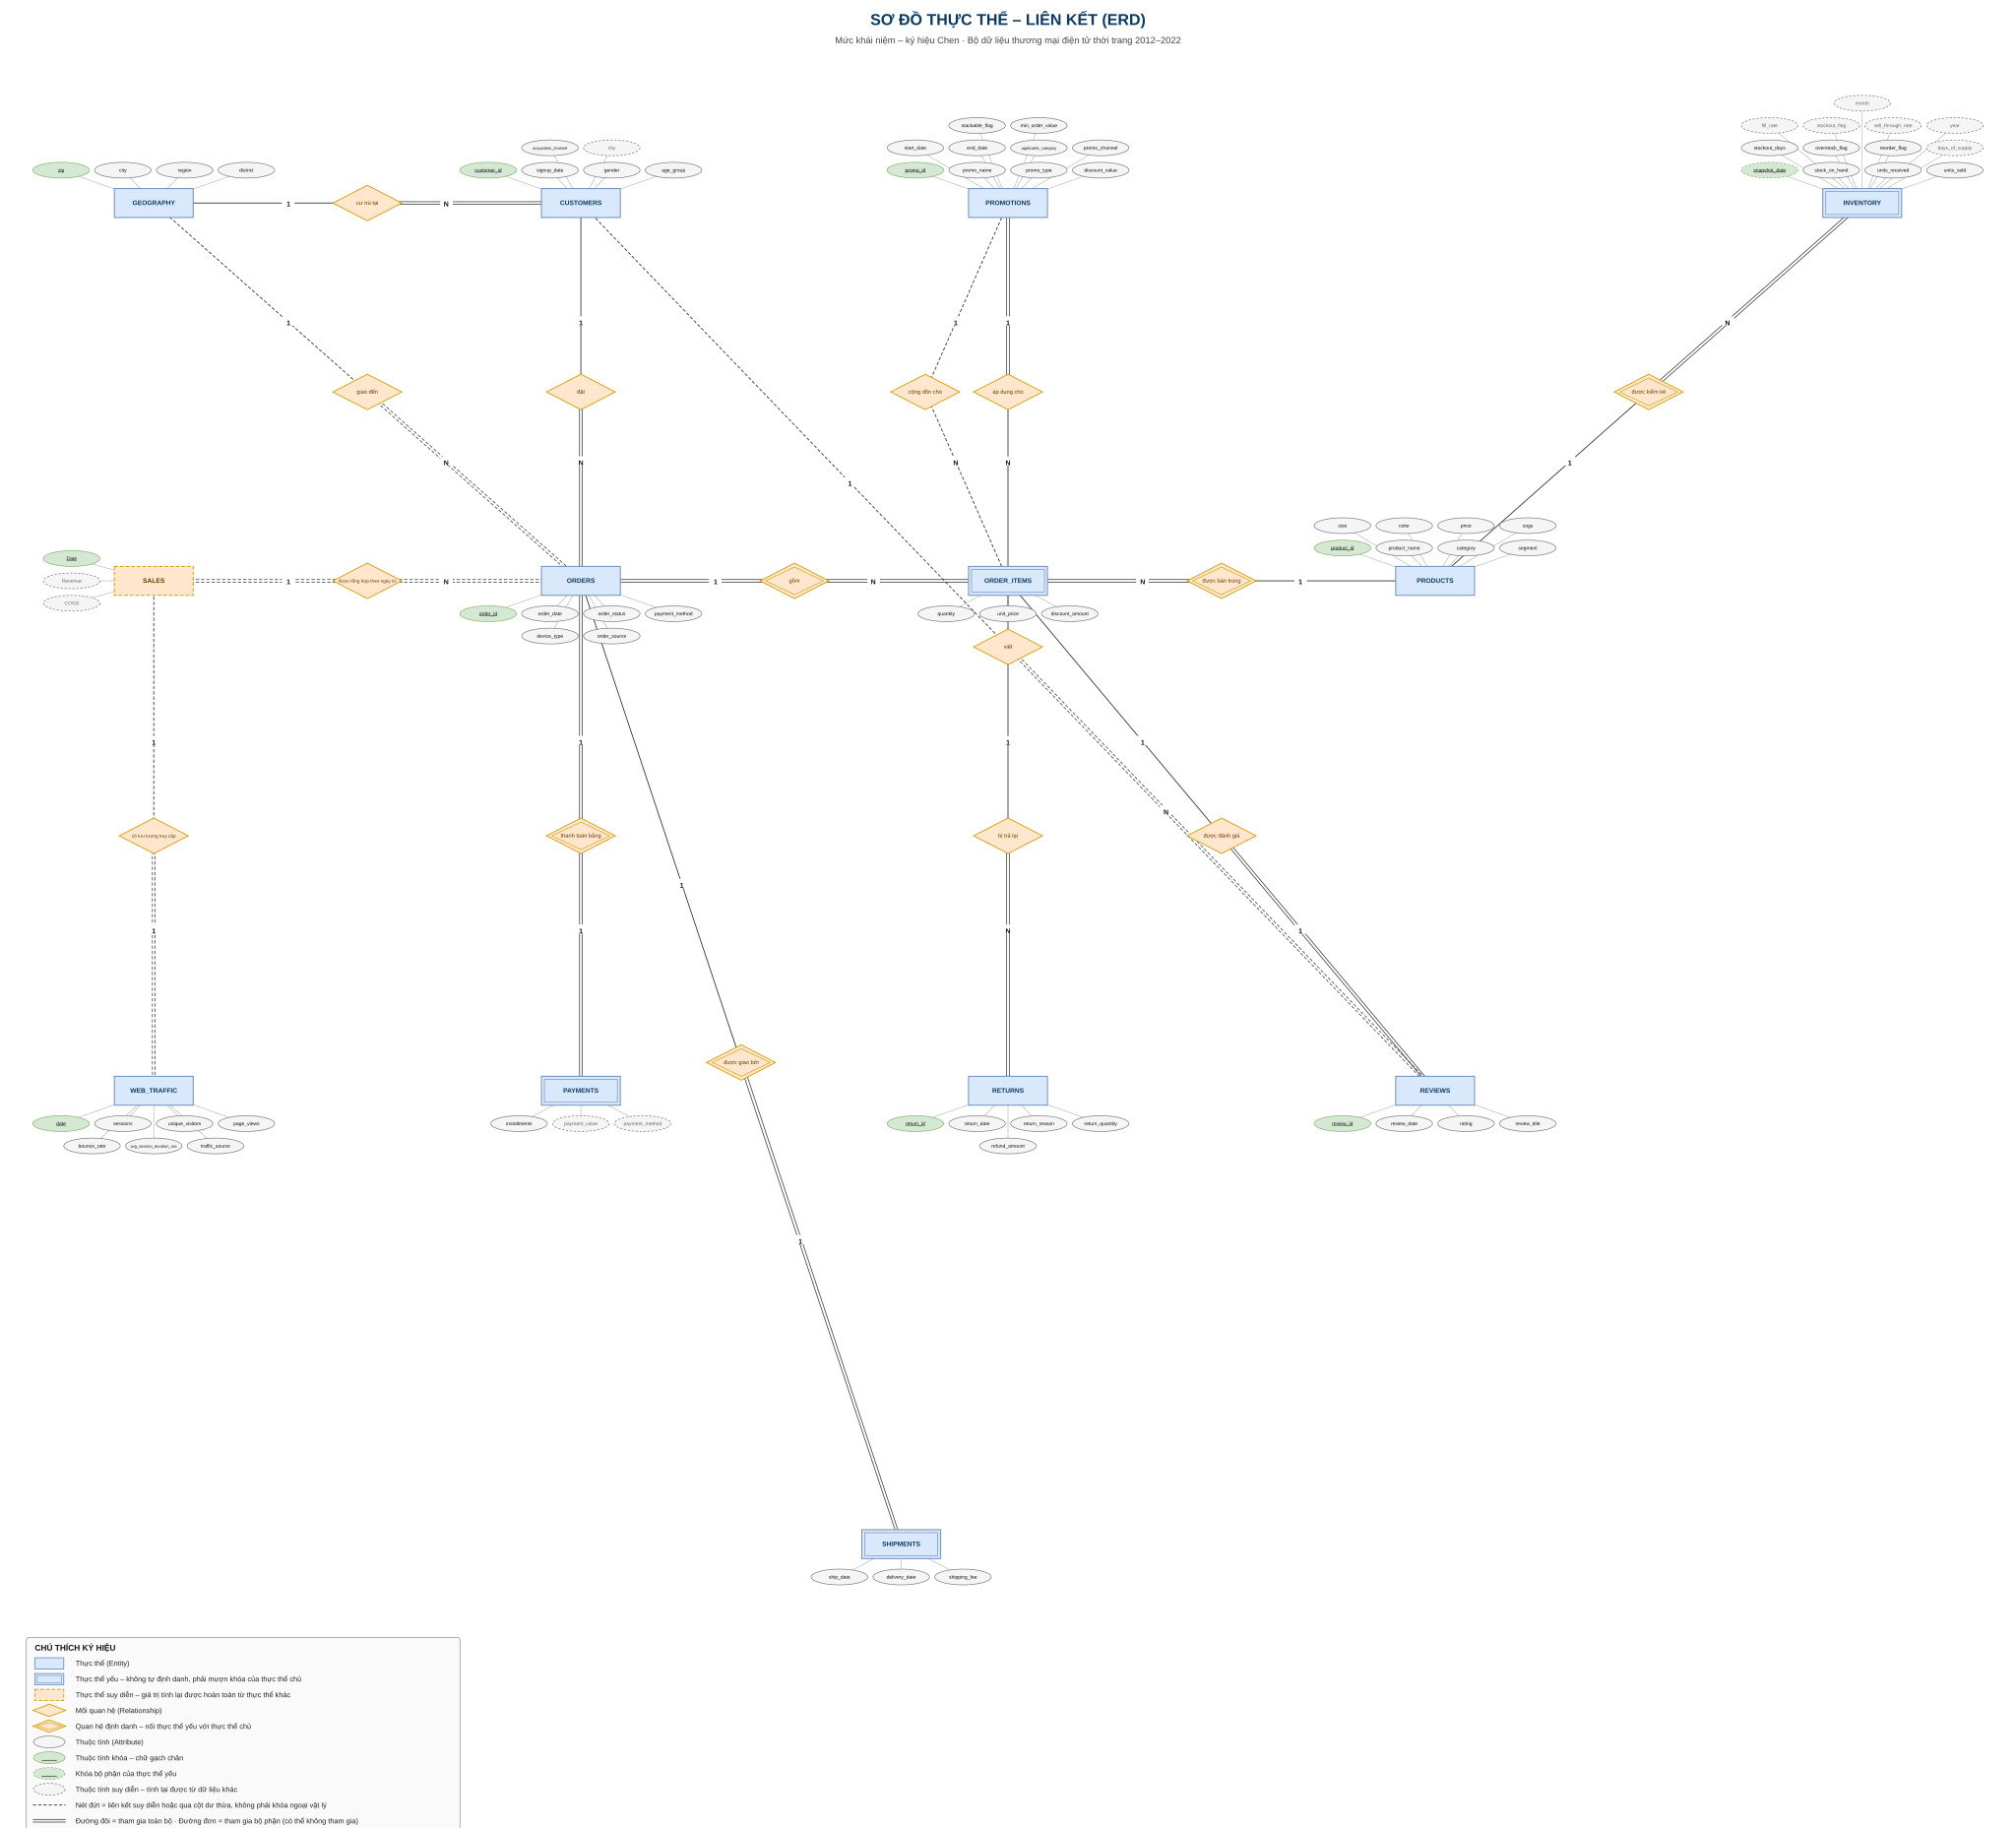

In [16]:
from IPython.display import SVG, display
display(SVG(filename='docs/erd.svg'))

## Ba quan hệ thiết kế đặc biệt

**`ORDER_ITEMS` → `RETURNS` / `REVIEWS`** — nối vào dòng hàng chứ không nối riêng vào `ORDERS`
và `PRODUCTS`, vì cặp `(order_id, product_id)` luôn đi cùng nhau (kiểm chứng ở Bước 7: 0 dòng lệch).

**`SALES` → `ORDERS`** — vẽ nét đứt. Trong CSV `sales` không có cột nào trỏ sang `orders`,
nhưng tập ngày của hai bảng **trùng khớp tuyệt đối**. Quan hệ có thật, chỉ nối qua giá trị ngày.

**`ORDER_ITEMS` là thực thể chứ không phải hình thoi** — trong ký hiệu Chen, quan hệ nhiều–nhiều
có thuộc tính thường vẽ thành hình thoi. Nhưng `ORDER_ITEMS` còn tham gia ba quan hệ khác với
`PROMOTIONS`, `RETURNS`, `REVIEWS`. Một quan hệ không thể có quan hệ con → buộc phải là thực thể.

---

# Tổng kết

## Sản phẩm hoàn thành

| Sản phẩm | Nội dung |
|---|---|
| Từ điển dữ liệu | 96 trường của 14 bảng, kèm **17 cảnh báo chất lượng** |
| Sơ đồ ERD | **13 thực thể · 75 thuộc tính · 15 quan hệ** |
| | 4 thực thể yếu · 1 thực thể suy diễn · 11 thuộc tính suy diễn |

## Kết quả kiểm định

| Nội dung | Kết quả |
|---|---|
| Toàn vẹn tham chiếu | 15 quan hệ · 4.815.470 bản ghi · **0 mồ côi** |
| Khóa chính | 8/9 bảng hợp lệ; `order_items` **không có** |
| Cột suy diễn | 5 công thức xác nhận, 1 giả thuyết bị bác bỏ |
| Biến mục tiêu | Tái tạo **sai số 0,00** trên 3.833/3.833 ngày |
| Đối soát thuộc tính | `93 − 15 − 3 = 75`, **khớp** với sơ đồ |
| Mâu thuẫn nghiệp vụ | 73,80% đơn đặt trước ngày đăng ký |

## Bốn cảnh báo quan trọng nhất cho bước mô hình hóa

1. **`Revenue` là doanh thu gộp**, tính cả đơn hủy và đơn trả — sai định nghĩa là sai target hoàn toàn
2. **Không dùng `signup_date`** cho bất kỳ đặc trưng nào
3. **Loại 11 cột suy diễn** trước khi huấn luyện để tránh đa cộng tuyến
4. **Thêm khóa thay thế cho `order_items`** trước khi nối bảng